In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
import zipfile
import os

# 1. Upload ZIP
uploaded = files.upload()

# 2. Extract ZIP
for fn in uploaded.keys():
    zip_path = fn                     # uploaded filename
    extract_dir = zip_path.replace(".zip", "")   # folder name without .zip

    # Make extraction folder
    os.makedirs(extract_dir, exist_ok=True)

    # Unzip
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print(f"✔ Extracted to: {extract_dir}")


Saving file_zip.zip to file_zip.zip
✔ Extracted to: file_zip


In [ ]:
import os
import shutil
import random

# --- PATH TO YOUR ORIGINAL DATASET ---
# Structure must be:
# original/
#    classA/
#    classB/
#    classC/
#    classD/
original_dir = "/content/extracted_folder/archive/data"

# --- OUTPUT DIRECTORIES ---
train_dir = "/content/train"
valid_dir = "/content/valid"
test_dir  = "/content/test"

for d in [train_dir, valid_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# --- SPLIT RATIOS ---
train_ratio = 0.70
valid_ratio = 0.20
test_ratio  = 0.10

# --- PROCESS EACH CLASS ---
for class_name in os.listdir(original_dir):
    class_path = os.path.join(original_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # make class folders in train/valid/test
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(valid_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir,  class_name), exist_ok=True)

    # get ALL images from class
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    valid_end = train_end + int(total * valid_ratio)

    # split
    train_files = images[:train_end]
    valid_files = images[train_end:valid_end]
    test_files  = images[valid_end:]

    # copy files
    for f in train_files:
        shutil.copy(os.path.join(class_path, f),
                    os.path.join(train_dir, class_name, f))

    for f in valid_files:
        shutil.copy(os.path.join(class_path, f),
                    os.path.join(valid_dir, class_name, f))

    for f in test_files:
        shutil.copy(os.path.join(class_path, f),
                    os.path.join(test_dir, class_name, f))

    print(f"Class '{class_name}': {len(train_files)} train, {len(valid_files)} val, {len(test_files)} test")


Class 'Common_Rust': 914 train, 261 val, 131 test
Class 'Gray_Leaf_Spot': 401 train, 114 val, 59 test
Class 'Healthy': 813 train, 232 val, 117 test
Class 'Blight': 802 train, 229 val, 115 test


In [ ]:
# Dataset paths
train_dir = '/content/train'
val_dir   = '/content/valid'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Data generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=(128,128), batch_size=32, class_mode='categorical'
)
val_data = val_gen.flow_from_directory(
    val_dir, target_size=(128,128), batch_size=32, class_mode='categorical'
)

# CNN model
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Found 2930 images belonging to 4 classes.
Found 836 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,        # limit epochs to avoid overfitting >85%
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 247ms/step - accuracy: 0.5341 - loss: 1.0073 - val_accuracy: 0.7763 - val_loss: 0.5560
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 211ms/step - accuracy: 0.7828 - loss: 0.5488 - val_accuracy: 0.8146 - val_loss: 0.4334
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.8233 - loss: 0.4702 - val_accuracy: 0.7895 - val_loss: 0.5331
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.8338 - loss: 0.4193 - val_accuracy: 0.7943 - val_loss: 0.5453
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.8318 - loss: 0.4137 - val_accuracy: 0.8110 - val_loss: 0.4667
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.8287 - loss: 0.3817 - val_accuracy: 0.8074 - val_loss: 0.4708
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.8348 - loss: 0.3659 - val_accuracy: 0.8684 - val_loss: 0.3321
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 195ms/step - accuracy: 0.8644 - loss: 0.3427 - val_accu

In [ ]:
loss, acc = model.evaluate(val_data)
print(f"Validation Accuracy: {acc*100:.2f}%")


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8084 - loss: 0.4584
Validation Accuracy: 81.58%


Model requires input size: (128, 128)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


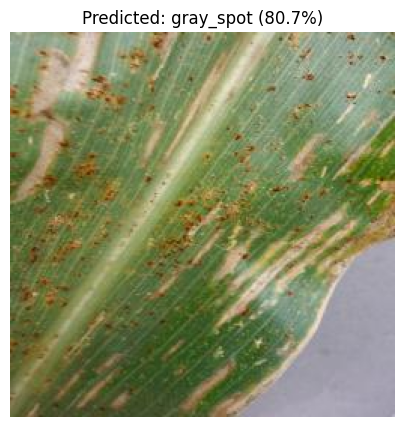

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image



# Automatically read the model's required input size
input_shape = model.input_shape[1:3]   # (H,W)
print("Model requires input size:", input_shape)

# ----------------------------------------------------
# Load + preprocess image correctly for your model
# ----------------------------------------------------
img_path = "/content/test/Gray_Leaf_Spot/Corn_Gray_Spot (172).JPG"   # change this
img = image.load_img(img_path, target_size=input_shape)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# ----------------------------------------------------
# Predict
# ----------------------------------------------------
pred = model.predict(img_array)[0]

# Your labels
classes = ["blight","common_rust","gray_spot","healthy"]  # adjust
predicted_class = classes[np.argmax(pred)]
confidence = np.max(pred)

# ----------------------------------------------------
# Display output
# ----------------------------------------------------
plt.figure(figsize=(5,5))
plt.imshow(image.load_img(img_path))
plt.axis("off")
plt.title(f"Predicted: {predicted_class} ({confidence*100:.1f}%)")
plt.show()


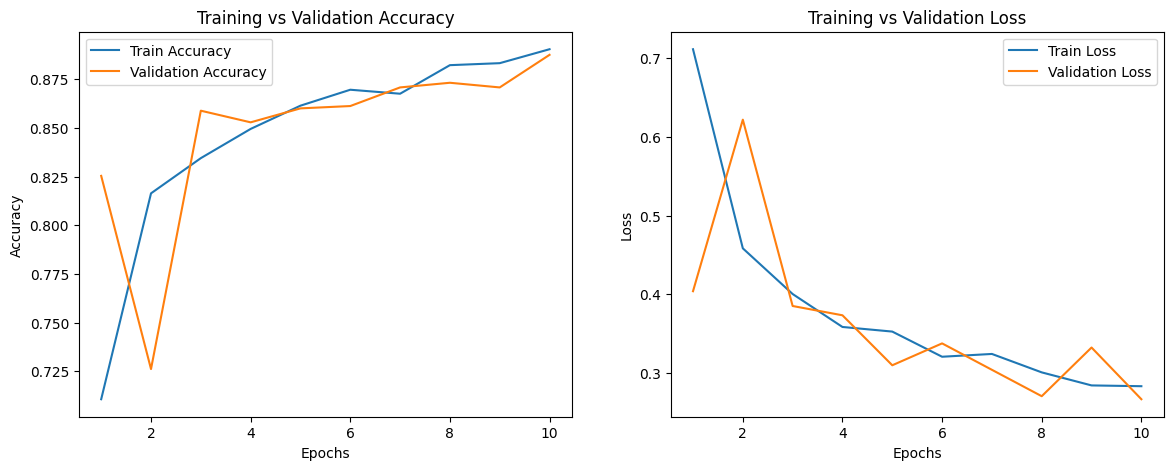

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


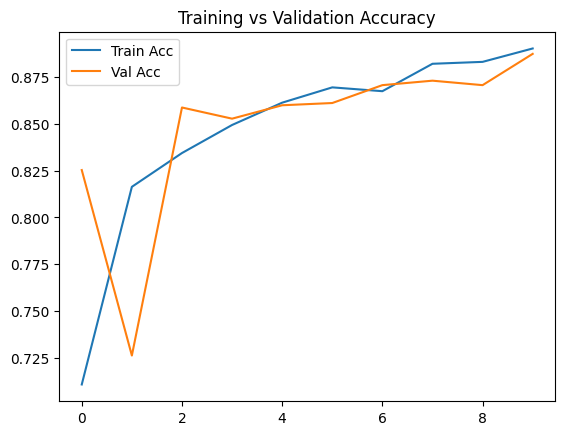

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Training vs Validation Accuracy"); plt.show()


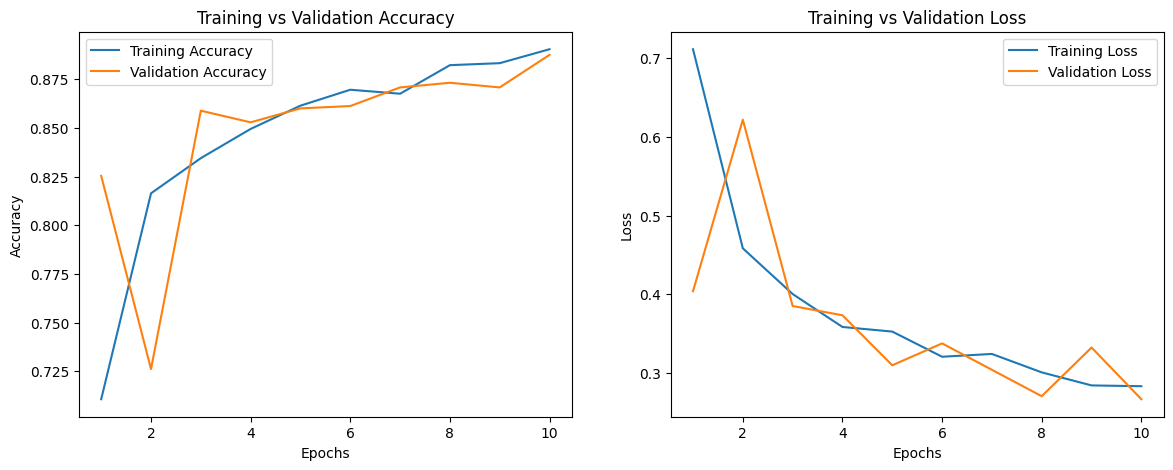

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    "/content/test",
    target_size=(128,128),   # or your model input size
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 422 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step


<Figure size 800x600 with 0 Axes>

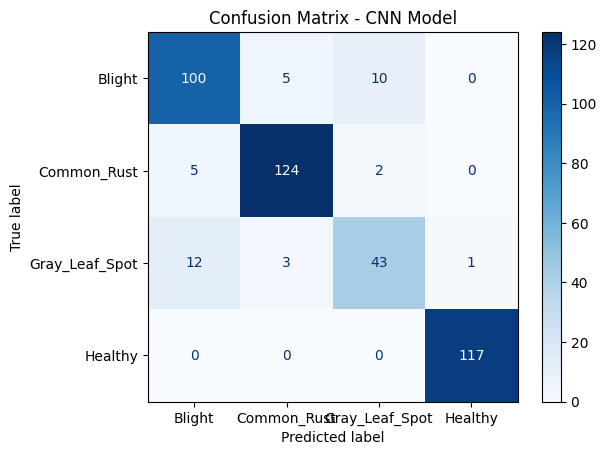

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

plt.figure(figsize=(8,6))
disp.plot(values_format='d', cmap="Blues")
plt.title("Confusion Matrix - CNN Model")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))


                precision    recall  f1-score   support

        Blight       0.85      0.87      0.86       115
   Common_Rust       0.94      0.95      0.94       131
Gray_Leaf_Spot       0.78      0.73      0.75        59
       Healthy       0.99      1.00      1.00       117

      accuracy                           0.91       422
     macro avg       0.89      0.89      0.89       422
  weighted avg       0.91      0.91      0.91       422



In [ ]:
train_loss, train_acc = model.evaluate(train_data, verbose=0)
val_loss, val_acc = model.evaluate(val_data, verbose=0)
test_loss, test_acc = model.evaluate(test_data, verbose=0)

import pandas as pd

df_cnn = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [train_acc, val_acc, test_acc],
    "Loss": [train_loss, val_loss, test_loss]
})

print(df_cnn)


      Dataset  Accuracy      Loss
0       Train  0.907167  0.233221
1  Validation  0.887560  0.266566
2        Test  0.909953  0.231426


In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))  # or your CNN input size
    img_arr = image.img_to_array(img)/255.0
    img_arr = np.expand_dims(img_arr, 0)

    preds = model.predict(img_arr)
    idx = np.argmax(preds)
    class_name = list(train_data.class_indices.keys())[idx]
    confidence = preds[0][idx]

    plt.imshow(image.load_img(img_path))
    plt.title(f"Predicted: {class_name} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

# Example usage:
# predict_image("/content/test/class1/example.jpg")


In [ ]:
model.save('/content/drive/MyDrive/maize_cnn_model.h5')
# Reload later:
# model = tf.keras.models.load_model('/content/drive/MyDrive/maize_cnn_model.h5')


In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("cnn_maize.tflite", "wb") as f:
    f.write(tflite_model)

print("CNN TFLite model saved as cnn_maize.tflite")


Saved artifact at '/tmp/tmpboukn8u2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137209663450832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663451600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663451216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663453712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663452944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663454672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663454096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663455056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663454480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137209663454288: TensorSpec(shape=(), dtype=tf.resource, name=None)
CNN TFLite model

In [ ]:
from google.colab import files
files.download("cnn_maize.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>